In [2]:
import pyodbc
import pandas as pd

# Connect to SQL Server
conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=.;'
    'DATABASE=NBA_Analytics;'
    'Trusted_Connection=yes;'
)

print("Connected successfully!")

Connected successfully!


In [4]:
with open('../Queries/Position Performance Analysis.sql', 'r') as file:
    query_q1 = file.read()

df_q1 = pd.read_sql(query_q1, conn)
print(df_q1)

  Pos  player_count  avg_points  avg_rebounds  avg_assists  avg_steals  \
0  PG            79        11.6           3.0          4.3         0.8   
1  PF            89        10.5           4.5          2.0         0.6   
2  SG           100        10.2           2.8          2.4         0.7   
3   C            83         9.3           6.1          1.7         0.6   
4  SF            95         9.1           3.4          1.7         0.7   

   avg_blocks  
0         0.3  
1         0.5  
2         0.3  
3         0.9  
4         0.4  


C:\Users\PC\AppData\Local\Temp\ipykernel_28660\1440664030.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q1 = pd.read_sql(query_q1, conn)


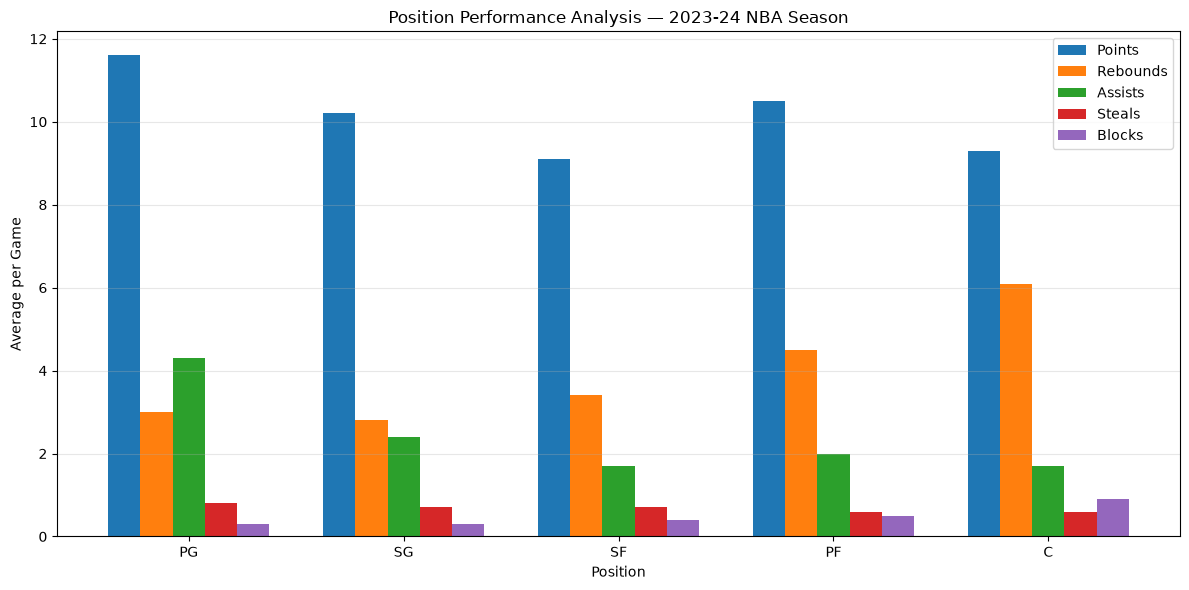

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Set position order logically (offense to defense flow)
df_q1 = df_q1.set_index('Pos').loc[['PG', 'SG', 'SF', 'PF', 'C']].reset_index()

stats = ['avg_points', 'avg_rebounds', 'avg_assists', 'avg_steals', 'avg_blocks']
labels = ['Points', 'Rebounds', 'Assists', 'Steals', 'Blocks']

x = np.arange(len(df_q1['Pos']))
width = 0.15

fig, ax = plt.subplots(figsize=(12, 6))

for i, (stat, label) in enumerate(zip(stats, labels)):
    ax.bar(x + i*width, df_q1[stat], width, label=label)

ax.set_xlabel('Position')
ax.set_ylabel('Average per Game')
ax.set_title('Position Performance Analysis — 2023-24 NBA Season')
ax.set_xticks(x + width*2)
ax.set_xticklabels(df_q1['Pos'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../Visualisation/q1_position_dominance.png', dpi=150)
plt.show()

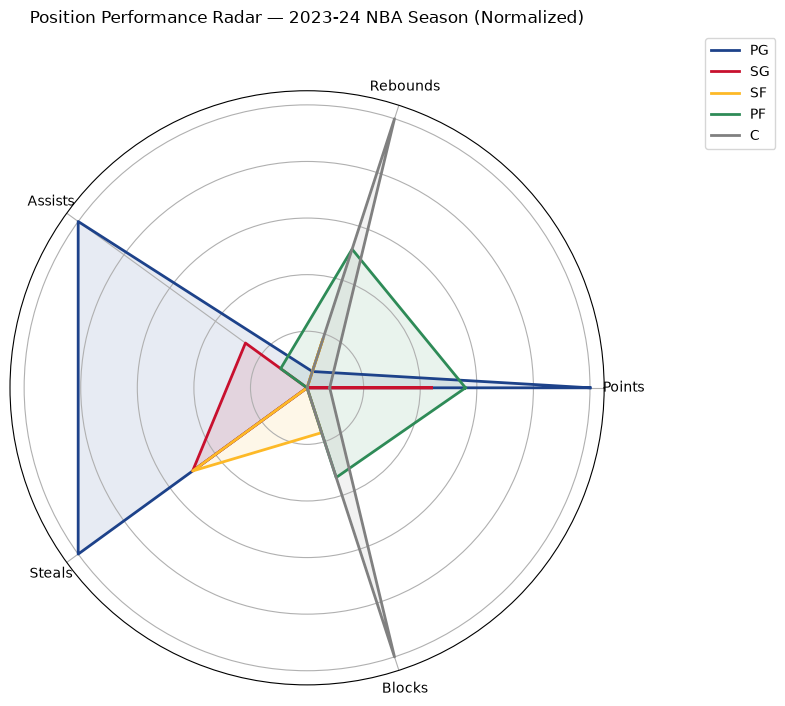

In [22]:
import numpy as np

NBA_BLUE = '#1d428a'

stats = ['avg_points', 'avg_rebounds', 'avg_assists', 'avg_steals', 'avg_blocks']
labels = ['Points', 'Rebounds', 'Assists', 'Steals', 'Blocks']

# Normalize each stat column to 0-1 scale
df_norm = df_q1.copy()
for stat in stats:
    df_norm[stat] = (df_q1[stat] - df_q1[stat].min()) / (df_q1[stat].max() - df_q1[stat].min())

num_vars = len(stats)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

colors = ['#1d428a', '#c8102e', '#fdb927', '#2e8b57', '#808080']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, row in df_norm.iterrows():
    values = row[stats].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row['Pos'], color=colors[i % len(colors)])
    ax.fill(angles, values, alpha=0.1, color=colors[i % len(colors)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_yticklabels([])  # hide the 0-1 scale numbers since they're not real units
ax.set_title('Position Performance Radar — 2023-24 NBA Season (Normalized)', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('../Visualisation/q1_radar_chart.png', dpi=150)
plt.show()

In [6]:
with open('../Queries/Team Offensive Output Analysis.sql', 'r') as file:
    query_q2 = file.read()

df_q2 = pd.read_sql(query_q2, conn)
print(df_q2)

   Team  Total Score  Total Assists  Avg Shooting Efficiency
0   TOR          223             58                     0.47
1   CHO          197             54                     0.45
2   PHI          188             42                     0.45
3   MEM          182             45                     0.45
4   NYK          180             34                     0.45
5   POR          176             39                     0.44
6   DET          173             38                     0.45
7   DAL          169             36                     0.49
8   MIA          164             39                     0.47
9   IND          163             40                     0.51
10  UTA          163             37                     0.47
11  ATL          157             36                     0.46
12  WAS          156             38                     0.47
13  PHO          155             36                     0.47
14  BRK          151             36                     0.46
15  BOS          149    

C:\Users\PC\AppData\Local\Temp\ipykernel_28660\1451911927.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q2 = pd.read_sql(query_q2, conn)


In [7]:
NBA_BLUE = '#1d428a'
NBA_RED = '#c8102e'
NBA_GOLD = '#fdb927'  # accent/highlight color
NBA_GRAY = '#cccccc'  # neutral/background bars

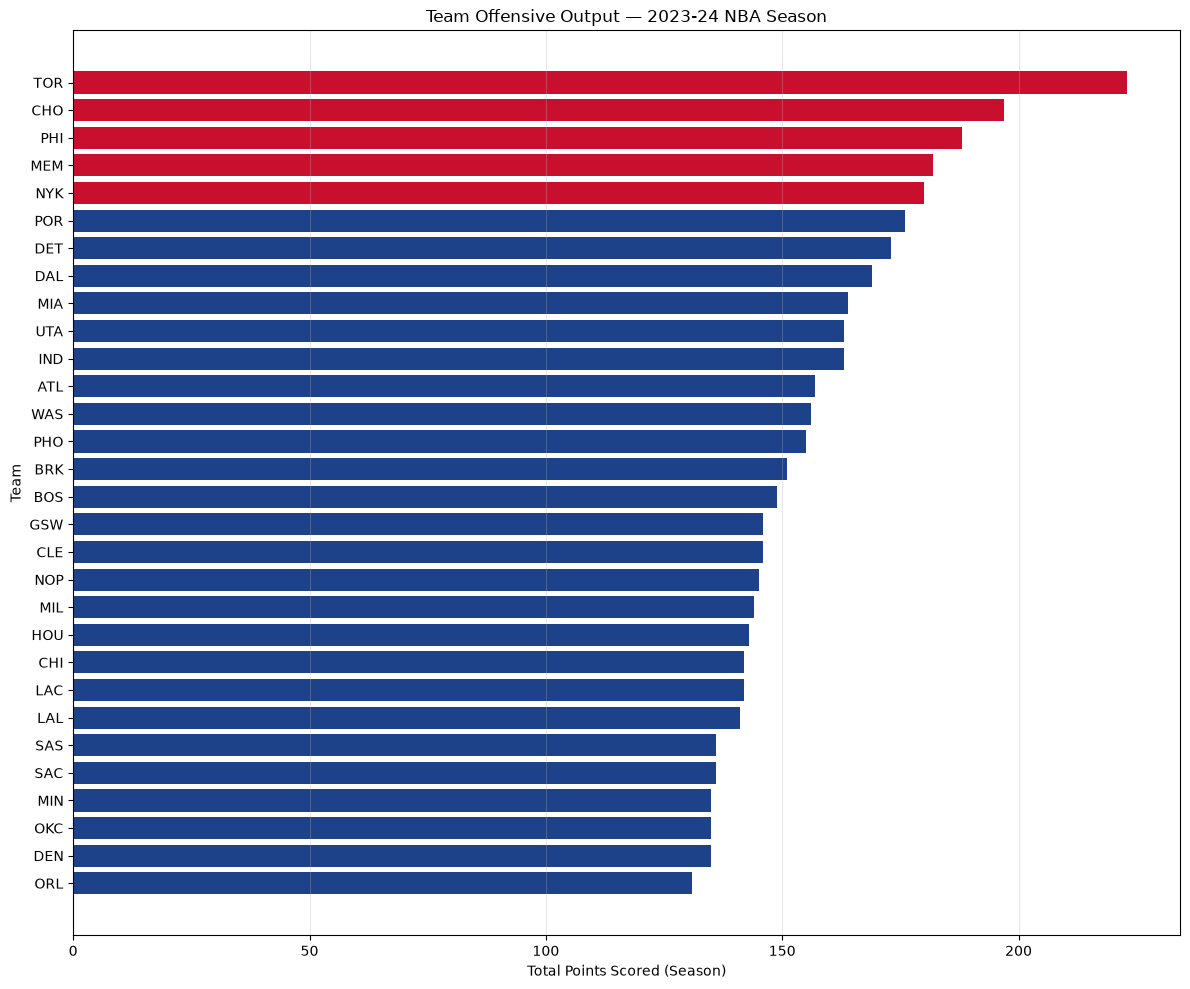

In [8]:

import matplotlib.colors as mcolors
df_q2 = df_q2.sort_values(by='Total Score', ascending=True)
colors = [NBA_RED if i >= len(df_q2)-5 else NBA_BLUE for i in range(len(df_q2))]

plt.figure(figsize=(12, 10))
plt.barh(df_q2['Team'], df_q2['Total Score'], color=colors)

plt.xlabel('Total Points Scored (Season)')
plt.ylabel('Team')
plt.title('Team Offensive Output — 2023-24 NBA Season')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../Visualisation/q2_team_offensive_output.png', dpi=150)
plt.show()

In [10]:
with open('../Queries/Position Outliers - Efficiency Z-Score Analysis.sql', 'r') as file:
    query_q3 = file.read()

df_q3 = pd.read_sql(query_q3, conn)
print(df_q3)
print(df_q3.columns.tolist())

                    Player Pos   Tm  player_efficiency  \
0         Ryan Arcidiacono  PG  NYK                0.6   
1            Maxwell Lewis  SF  LAL                0.4   
2        Wendell Moore Jr.  SG  MIN                1.4   
3   Thanasis Antetokounmpo  PF  MIL                1.7   
4        Admiral Schofield  PF  ORL                1.9   
5         Chris Livingston  SF  MIL                2.3   
6                 Jay Huff   C  DEN                2.1   
7              Braxton Key  SF  DEN                2.6   
8          Jerome Robinson  SG  GSW                1.9   
9              Josh Minott  SF  MIN                2.7   
10         Kessler Edwards  SF  SAC                3.0   
11     Jalen Hood-Schifino  SG  LAL                2.4   
12           Jalen Pickett  SG  DEN                2.7   
13            Terry Taylor  PF  CHI                3.1   
14           Dalano Banton  PG  BOS                4.5   
15              AJ Griffin  SF  ATL                3.4   
16         Jul

C:\Users\PC\AppData\Local\Temp\ipykernel_28660\2611738898.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q3 = pd.read_sql(query_q3, conn)


In [11]:
query_q3_all = """
WITH PositionStats AS (
    SELECT
        Pos,
        ROUND(AVG(PTS + TRB + AST + STL + BLK - TOV), 2)      AS avg_efficiency_per_role,
        ROUND(STDEV(PTS + TRB + AST + STL + BLK - TOV), 2)    AS stdev_efficiency_per_role
    FROM nba_players
    WHERE Tm != 'TOT'
    AND G >= 20
    GROUP BY Pos
)
SELECT
    p.Player,
    p.Pos,
    p.Tm,
    ROUND(p.PTS + p.TRB + p.AST + p.STL + p.BLK - p.TOV, 2)   AS player_efficiency,
    ROUND(((p.PTS + p.TRB + p.AST + p.STL + p.BLK - p.TOV) - ps.avg_efficiency_per_role) / ps.stdev_efficiency_per_role, 2) AS z_score
FROM nba_players p
JOIN PositionStats ps ON p.Pos = ps.Pos
WHERE p.Tm != 'TOT'
AND p.G >= 20
"""

df_q3_all = pd.read_sql(query_q3_all, conn)
print(df_q3_all.shape)
print(df_q3_all.head())

(466, 5)
             Player Pos   Tm  player_efficiency  z_score
0  Precious Achiuwa   C  TOR               14.8    -0.26
1       Bam Adebayo   C  MIA               33.3     1.56
2     Jarrett Allen   C  CLE               29.9     1.23
3     Deandre Ayton   C  POR               29.4     1.18
4        Ibou Badji   C  POR                4.7    -1.25


C:\Users\PC\AppData\Local\Temp\ipykernel_28660\3522609707.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q3_all = pd.read_sql(query_q3_all, conn)


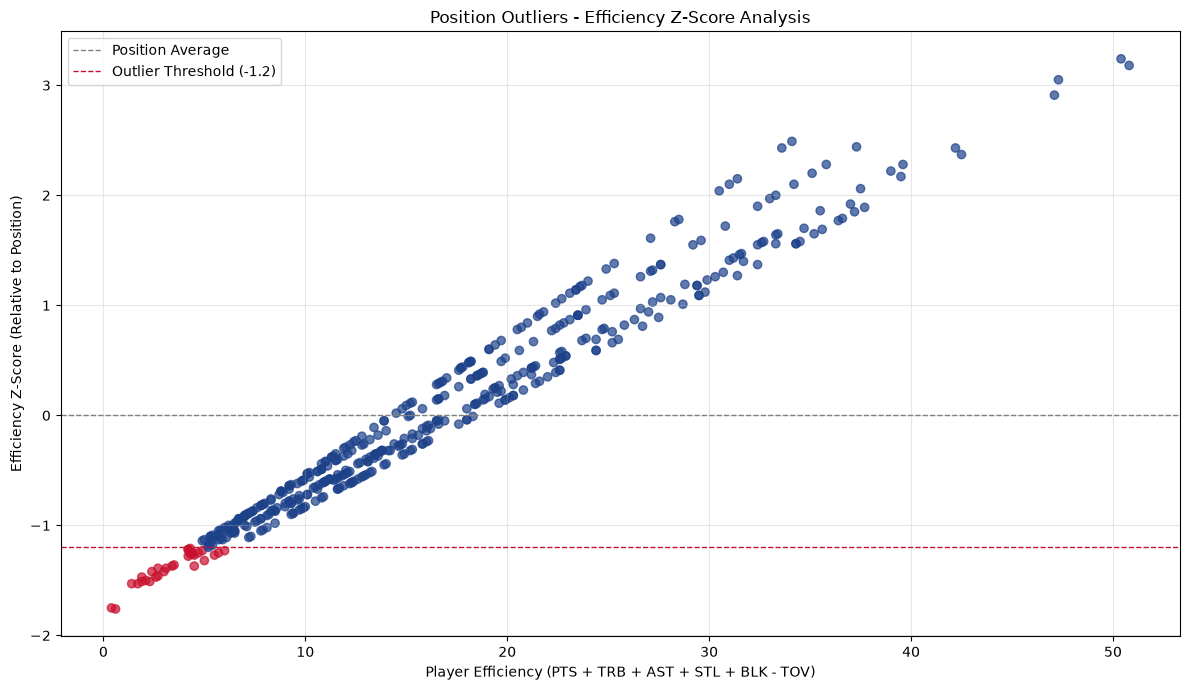

In [13]:
colors = [NBA_RED if z < -1.2 else NBA_BLUE for z in df_q3_all['z_score']]

plt.figure(figsize=(12, 7))
plt.scatter(df_q3_all['player_efficiency'], df_q3_all['z_score'], color=colors, alpha=0.7)

plt.axhline(0, color='gray', linestyle='--', linewidth=1, label='Position Average')
plt.axhline(-1.2, color=NBA_RED, linestyle='--', linewidth=1, label='Outlier Threshold (-1.2)')

plt.xlabel('Player Efficiency (PTS + TRB + AST + STL + BLK - TOV)')
plt.ylabel('Efficiency Z-Score (Relative to Position)')
plt.title('Position Outliers - Efficiency Z-Score Analysis')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../Visualisation/q3_position_outliers.png', dpi=150)
plt.show()

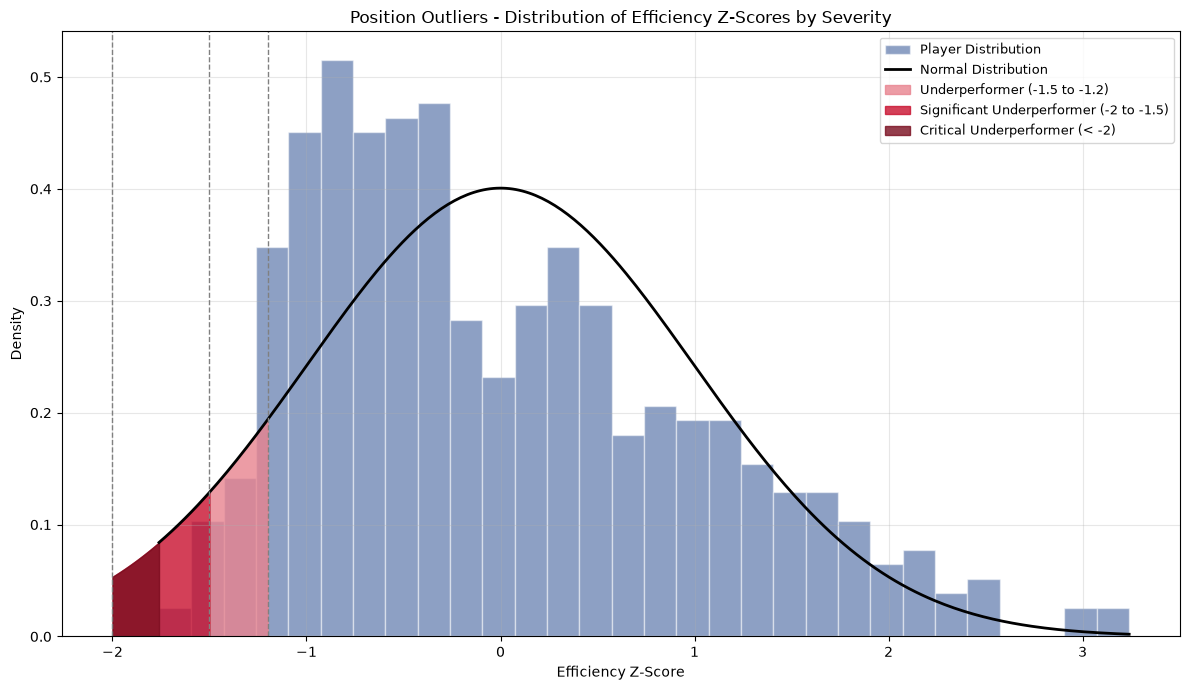

In [16]:
import numpy as np
from scipy.stats import norm

NBA_BLUE = '#1d428a'
CRITICAL = '#7a0d1f'      # darkest red
SIGNIFICANT = '#c8102e'   # NBA red
UNDERPERFORM = '#e8838f'  # light red

z_scores = df_q3_all['z_score']
mu, std = z_scores.mean(), z_scores.std()

plt.figure(figsize=(12, 7))

# Histogram of actual z-scores
plt.hist(z_scores, bins=30, density=True, color=NBA_BLUE, alpha=0.5, edgecolor='white', label='Player Distribution')

# Normal distribution curve
x = np.linspace(z_scores.min(), z_scores.max(), 300)
plt.plot(x, norm.pdf(x, mu, std), color='black', linewidth=2, label='Normal Distribution')

# Zone 1: Underperformer (-1.5 to -1.2)
x1 = np.linspace(-1.5, -1.2, 50)
plt.fill_between(x1, norm.pdf(x1, mu, std), color=UNDERPERFORM, alpha=0.8, label='Underperformer (-1.5 to -1.2)')

# Zone 2: Significant Underperformer (-2 to -1.5)
x2 = np.linspace(-2, -1.5, 50)
plt.fill_between(x2, norm.pdf(x2, mu, std), color=SIGNIFICANT, alpha=0.8, label='Significant Underperformer (-2 to -1.5)')

# Zone 3: Critical Underperformer (below -2)
x3 = np.linspace(z_scores.min(), -2, 50)
plt.fill_between(x3, norm.pdf(x3, mu, std), color=CRITICAL, alpha=0.8, label='Critical Underperformer (< -2)')

plt.axvline(-1.2, color='gray', linestyle='--', linewidth=1)
plt.axvline(-1.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(-2, color='gray', linestyle='--', linewidth=1)

plt.xlabel('Efficiency Z-Score')
plt.ylabel('Density')
plt.title('Position Outliers - Distribution of Efficiency Z-Scores by Severity')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../Visualisation/q3_position_outliers.png', dpi=150)
plt.show()

In [17]:
with open('../Queries/Dead Weight - High Minutes Low Efficiency.sql', 'r') as file:
    query_q4 = file.read()

df_q4 = pd.read_sql(query_q4, conn)
print(df_q4)

                      Player Pos   Tm    MP  efficiency
0              Isaiah Livers  PF  DET  20.4         8.3
1                Cam Reddish  SF  LAL  20.5         9.2
2                Maxi Kleber   C  DAL  20.3         9.7
3                Amir Coffey  SF  LAC  20.9        10.1
4             Quentin Grimes  SG  NYK  20.2        10.8
5                Gary Harris  SG  ORL  24.0        10.8
6           Matisse Thybulle  SF  POR  22.9        10.8
7                 Vit Krejci  PG  ATL  24.6        10.8
8          Spencer Dinwiddie  PG  LAL  24.2        10.9
9            Pat Connaughton  SF  MIL  22.1        11.0
10                 Dean Wade  PF  CLE  20.5        11.0
11               Jae Crowder  PF  MIL  23.1        11.2
12         Haywood Highsmith  PF  MIA  20.7        11.2
13               Kris Murray  SF  POR  21.7        11.3
14             Cason Wallace  SG  OKC  20.6        11.5
15              Ochai Agbaji  SG  TOR  23.6        11.5
16               Gradey Dick  SG  TOR  21.1     

C:\Users\PC\AppData\Local\Temp\ipykernel_28660\3441702286.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q4 = pd.read_sql(query_q4, conn)


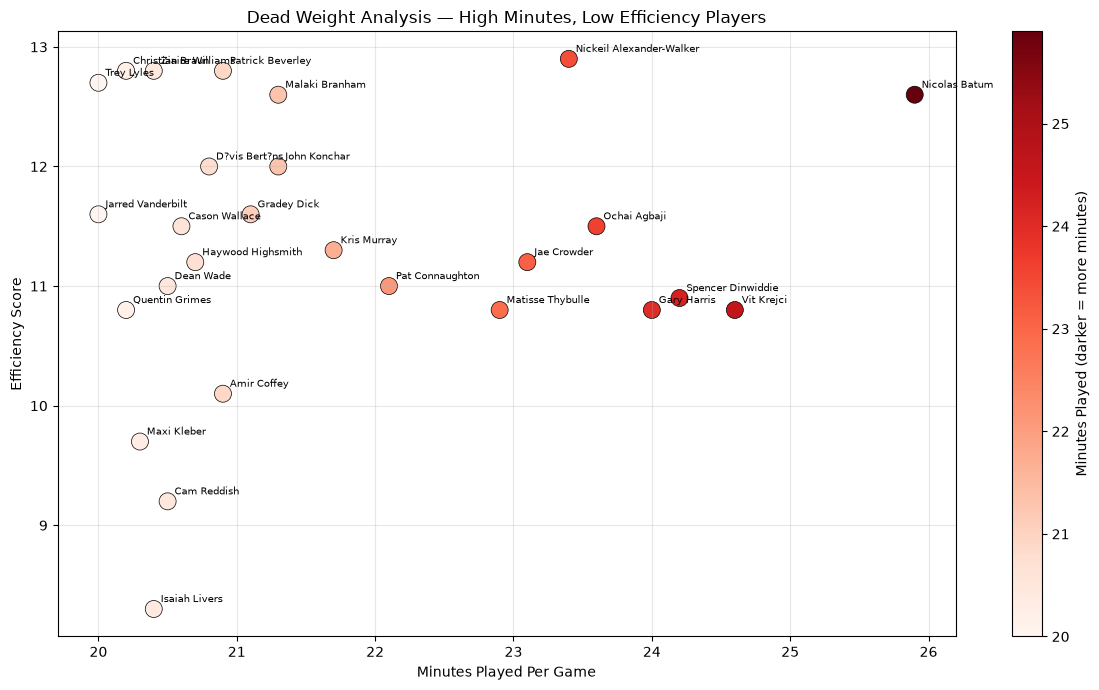

In [18]:
plt.figure(figsize=(12, 7))

# Color intensity based on how "bad" the combination is - normalize MP for color scaling
scatter = plt.scatter(
    df_q4['MP'], 
    df_q4['efficiency'], 
    c=df_q4['MP'], 
    cmap='Reds', 
    s=150, 
    edgecolor='black', 
    linewidth=0.5
)

# Label each point with player name
for i, row in df_q4.iterrows():
    plt.annotate(row['Player'], (row['MP'], row['efficiency']), 
                 fontsize=7, xytext=(5, 5), textcoords='offset points')

plt.colorbar(scatter, label='Minutes Played (darker = more minutes)')

plt.xlabel('Minutes Played Per Game')
plt.ylabel('Efficiency Score')
plt.title('Dead Weight Analysis — High Minutes, Low Efficiency Players')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../Visualisation/q4_dead_weight.png', dpi=150)
plt.show()